In [106]:
%matplotlib widget
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [107]:
df = pd.read_csv("final_data.csv")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [108]:
bmi = df.BMI
fat_p = df.Fat_Percentage
calories = df.Calories
weight=df["Weight (kg)"]

Text(42.722222222222214, 0.5, 'BMI')

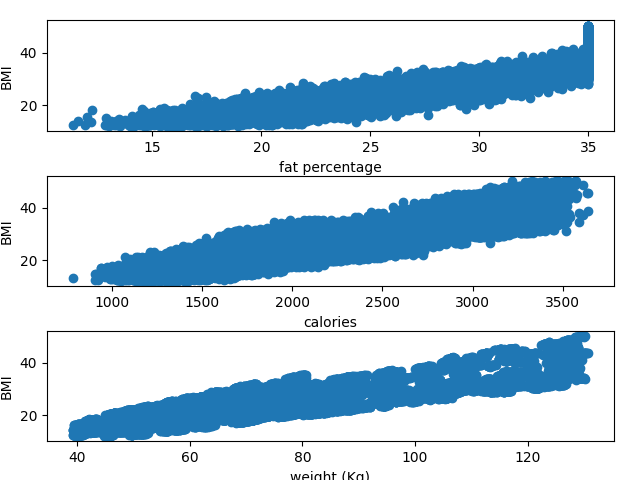

In [109]:
fig1,(ax11,ax12,ax13) = plt.subplots(3)
fig1.tight_layout()
ax11.scatter(fat_p,bmi)
ax11.set_xlabel("fat percentage")
ax11.set_ylabel("BMI")
ax12.scatter(calories,bmi)
ax12.set_xlabel("calories")
ax12.set_ylabel("BMI")
ax13.scatter(weight,bmi)
ax13.set_xlabel("weight (Kg)")
ax13.set_ylabel("BMI")

In [110]:
#my-gradient descent and scale function
def scale(x:np.ndarray,scaling:int=0):
    """
    x (ndarray) : feature values
    scaling (int) : Scaling Technique
    0 (feature scaling) : min/max < x/max < max/max
    1 (mean normalization) :  x = (x-mean)/max-min
    2 (z-score normalization) : x = (x-mean)/standard-deviation
    """

    match scaling:
        case 0:
            return x/x.max()
        case 1:
            mean=x.mean()
            return (x-mean)/(x.max()-x.min())
        case 2: 
            mean=x.mean()
            std=x.std()
            return (x-mean)/std
        case _:
            raise ValueError("Invalid input!")

def linear_regression_gradient_descent(x:np.ndarray,y:np.ndarray,w_i:float=0,b_i:float=0,alpha:float=0.001,iters:int=1000,cost:bool=False):
    """
    x (ndarray) : feature values shape(n feature,m samples)
    y (ndarray) : target values
    w_i (float) : initial regression coefficient
    b_i (float) : initial interception value
    alpha (float) : value of learning rate
    iters (int) : number of gradient descent iterations
    cost (bool) : return cost function and number of iteration for learning curve
    """
    w=w_i
    b=b_i
    a=alpha
    m = len(x)      #total values
    cost_history=[]    #saving data for learning curve
    x_iters=np.arange(0,iters)
    for _ in range(iters):
        #Model function
        f_wb=w*x+b
        #cost function
        j_wb=(1/(2*m)) * np.sum((f_wb - y)**2)
        #derivatives
        dj_dw = (1/m) * np.sum((f_wb - y) * x)
        dj_db = (1/m) * np.sum((f_wb - y))
        cost_history.append(j_wb)
        #gradient descent
        w-= a*dj_dw
        b-= a*dj_db
    match cost:
        case False:
           return w,b
        case True:
            return w,b,cost_history,x_iters
        case _ :
            raise ValueError("Invalid input!")

In [111]:
y=bmi
x11=fat_p
x12=calories
x13 = weight
x11=scale(x11,2)
x12=scale(x12,2)
x13=scale(x13,2)
w11,b11,cost11,iters11=linear_regression_gradient_descent(x11,y,alpha=0.1,cost=True)
w12,b12=linear_regression_gradient_descent(x12,y,alpha=0.1)
w13,b13=linear_regression_gradient_descent(x13,y,alpha=0.1)

Text(0, 0.5, 'cost')

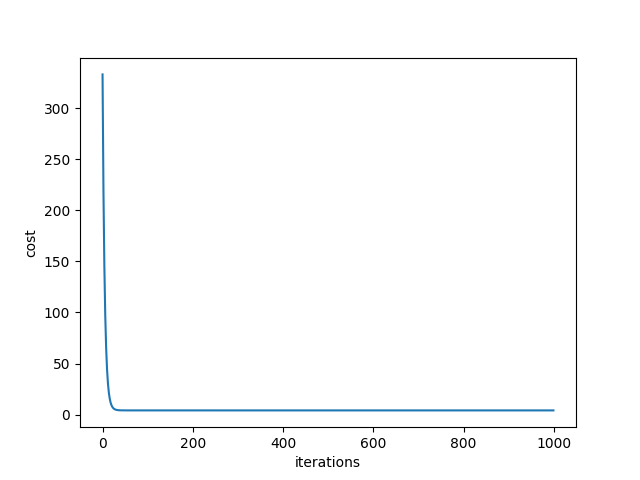

In [112]:
#ploting the cost
plt_cost1=plt.figure().add_subplot(111,)
plt_cost1.plot(iters11,cost11)
plt_cost1.set_xlabel("iterations")
plt_cost1.set_ylabel("cost")

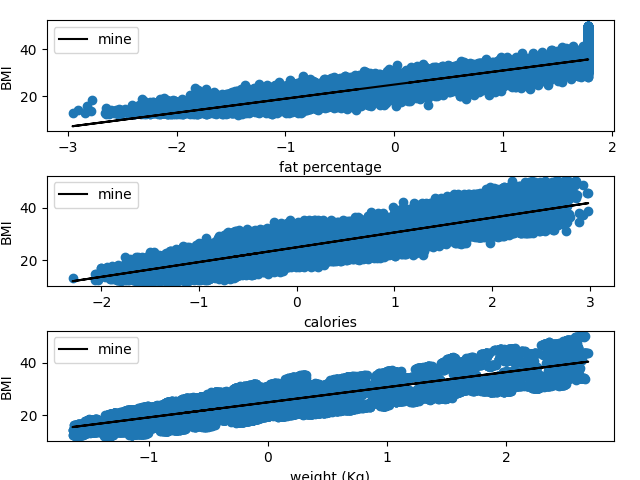

In [113]:
fig2,(ax21,ax22,ax23) = plt.subplots(3)
f11=w11*x11 + b11
f12=w12*x12 + b12
f13=w13*x13 + b13
fig2.tight_layout()
ax21.scatter(x11,y)
ax21.plot(x11,f11,label="mine",c="black")
ax21.set_xlabel("fat percentage")
ax21.set_ylabel("BMI")
ax21.legend()
ax22.scatter(x12,y)
ax22.plot(x12,f12,label="mine",c="black")
ax22.set_xlabel("calories")
ax22.set_ylabel("BMI")
ax22.legend()
ax23.scatter(x13,y)
ax23.plot(x13,f13,label="mine",c="black")
ax23.set_xlabel("weight (Kg)")
ax23.set_ylabel("BMI")
ax23.legend()

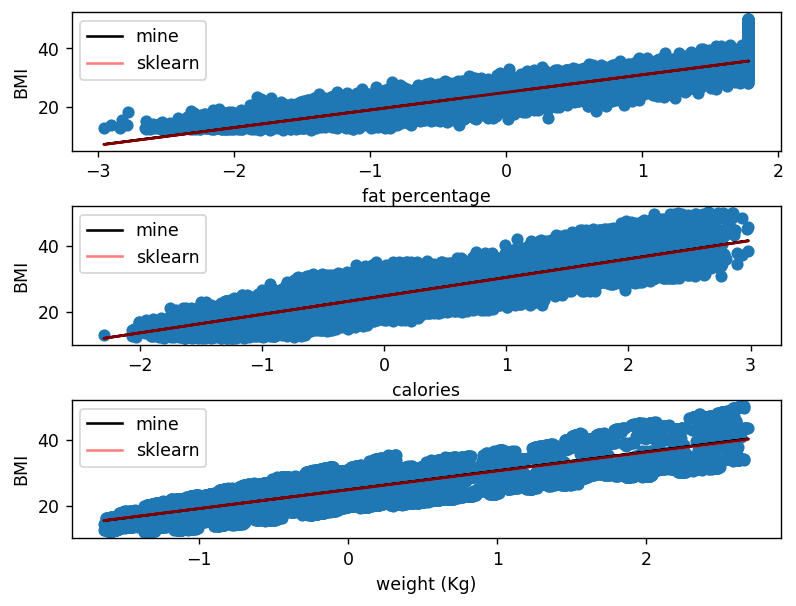

In [114]:
xs11=fat_p.to_numpy()
xs11=np.reshape(xs11,(-1,1))
xs12=calories.to_numpy()
xs12=np.reshape(xs12,(-1,1))
xs13=weight.to_numpy()
xs13=np.reshape(xs13,(-1,1))
standardizer = sklearn.preprocessing.StandardScaler()
model1 = sklearn.linear_model.SGDRegressor()

xs11=standardizer.fit_transform(xs11)
xs12=standardizer.fit_transform(xs12)
xs13=standardizer.fit_transform(xs13)

model1.fit(xs11,y)
ax21.plot(xs11,model1.predict(xs11),label="sklearn",alpha=0.5,c="red")
ax21.legend()
x1=standardizer.fit_transform(xs12)
model1.fit(xs12,y)
ax22.plot(xs12,model1.predict(xs12),label="sklearn",alpha=0.5,c="red")
ax22.legend()
fig2
model1.fit(xs13,y)
ax23.plot(xs13,model1.predict(xs13),label="sklearn",alpha=0.5,c="red")
ax23.legend()
fig2

In [115]:
#multiple linear regression.
def multiple_linear_regression_gradient_descent(*x:np.ndarray,y:np.ndarray,w_i:float=0,b_i:float=0,alpha:float=0.001,iters:int=1000,cost:bool=False):
    """
    *x (ndarray) : features values
    y (ndarray) : target values
    w_i (float) : initial regression coefficient
    b_i (float) : initial interception value
    alpha (float) : value of learning rate
    iters (int) : number of gradient descent iterations
    cost (bool) : return cost function and number of iteration for learning curve
    """
    x=np.array(x)
    y=np.array(y)
    w=np.full((x.shape[0],1),w_i,dtype="float64")
    b=b_i
    m=x.shape[1]
    a=alpha
    cost_history=[]    #saving data for learning curve
    x_iters=np.arange(0,iters)
    for _ in range(iters):
        f_wb = np.dot(w.T,x) + b
        j_wb=(1/(2*m)) * np.sum((f_wb - y)**2)

        dj_dw = (1/m) * np.dot((f_wb-y),x.T) #1*2
        dj_db = (1/m) * np.sum((f_wb-y))
        cost_history.append(j_wb)

        w-= a*dj_dw.T
        b-= a*dj_db
    match cost:
        case False:
           return w,b
        case True:
            return w,b,cost_history,x_iters
        case _ :
            raise ValueError("Invalid input!")

In [116]:
x21=fat_p
x22=calories
x23=weight
x21=scale(x21,2)
x22=scale(x22,2)
x23=scale(x23,2)
w2,b2,cost2,iters2=multiple_linear_regression_gradient_descent(x21,x22,x23,y=y.to_numpy(),alpha=0.1,cost=True)

Text(0, 0.5, 'cost')

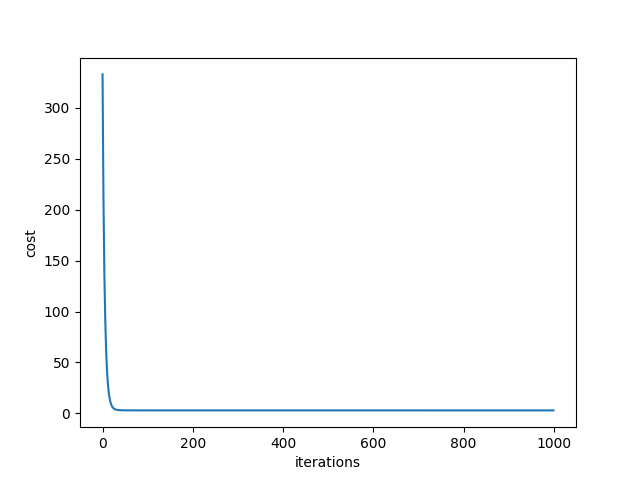

In [117]:
plt_cost2=plt.figure().add_subplot(111,)
plt_cost2.plot(iters2,cost2)
plt_cost2.set_xlabel("iterations")
plt_cost2.set_ylabel("cost")

In [118]:
#removing one feature to plot easily
x21=fat_p
x23=weight
x21=scale(x21,2)
x23=scale(x23,2)
w2,b2,cost2,iters2=multiple_linear_regression_gradient_descent(x21,x23,y=y.to_numpy(),alpha=0.1,cost=True)

Text(0.5, 0, 'BMI')

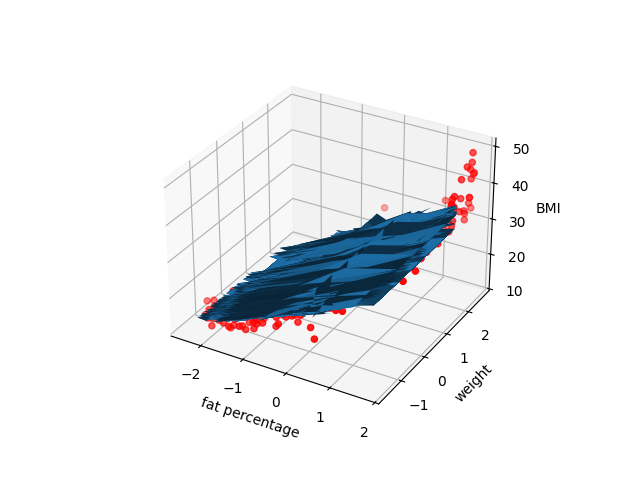

In [119]:
x2=np.array((x21[:500],x23[:500]))
X21,X23 = np.meshgrid(x21[:500],x23[:500])
f2 = np.dot(w2.T,x2)+ b2
fig3=plt.figure()
ax3 = fig3.add_subplot(111,projection="3d")
ax3.plot_surface(X21,X23,f2,label="mine")
ax3.scatter(x21[:500],x23[:500],y[:500],color="red")
ax3.set_xlabel("fat percentage")
ax3.set_ylabel("weight")
ax3.set_zlabel("BMI")

In [120]:
#sklearn multiple linear regression
xs21=fat_p.to_numpy().reshape((-1,1))
xs23=weight.to_numpy().reshape((-1,1))
standardizer = sklearn.preprocessing.StandardScaler()
model2 = sklearn.linear_model.SGDRegressor()

xs21=standardizer.fit_transform(xs21)
xs23=standardizer.fit_transform(xs23)
xs2=np.hstack((xs21,xs23))
model2.fit(xs2,y)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


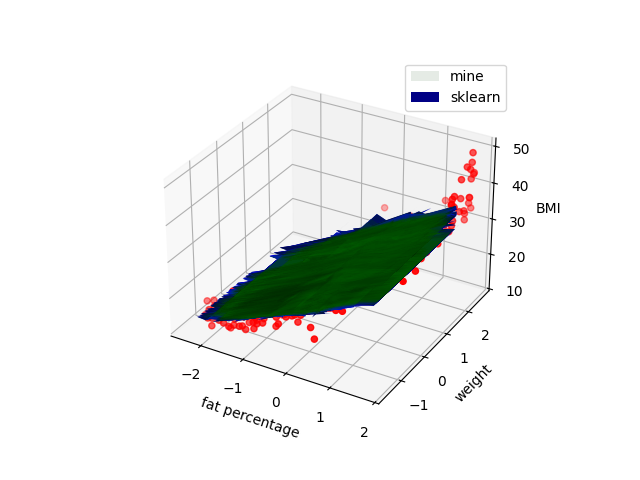

In [121]:

XS21,XS23 = np.meshgrid(xs21[:500],xs23[:500])
fs2 = model2.predict(xs2)
fs2=fs2.reshape((1,-1))
fig4=plt.figure()
ax4 = fig4.add_subplot(111,projection="3d",)
ax4.plot_surface(X21,X23,f2,label="mine",color="green" ,alpha=0.1)
ax4.plot_surface(XS21,XS23,fs2[:,:500],label="sklearn",alpha=1,color="blue")
ax4.scatter(x21[:500],x23[:500],y[:500],color="red")
ax4.set_xlabel("fat percentage")
ax4.set_ylabel("weight")
ax4.set_zlabel("BMI")
ax4.legend()

In [122]:
#Polynomial regression
def polynomial_regression_gradient_descent(*x:tuple,y:np.ndarray,w_i:float=0,b_i:float=0,alpha:float=0.001,iters:int=1000,cost:bool=False):
    """
    *x (tuple) : features values and their exponent | (x:ndarray,e:float)
    y (ndarray) : target values
    w_i (float) : initial regression coefficient
    b_i (float) : initial interception value
    alpha (float) : value of learning rate
    iters (int) : number of gradient descent iterations
    cost (bool) : return cost function and number of iteration for learning curve
    """
    w=np.full(len(x),w_i,dtype="float64").reshape((1,-1))
    b=b_i
    a=alpha
    xa=[]
    e=[]
    for i in range(len(x)):
        xa.append(x[i][0])
    for i in range(len(x)):
        e.append(x[i][1])
    x=np.array(xa)
    e=np.array(e)
    m=len(x[0])
    x=np.power(x.T,e)
    cost_history=[]    #saving data for learning curve
    x_iters=np.arange(0,iters)
    for _ in range(iters):
        f_wb=np.dot(w,x.T) + b
        j_wb=(1/(2*m)) * np.sum((f_wb - y)**2)
        
        dj_dw = (1/m) * np.dot((f_wb-y),x)
        dj_db = (1/m) * np.sum((f_wb-y))
        cost_history.append(j_wb)
        
        w-=a*dj_dw
        b-=a*dj_db
    match cost:
        case False:
           return w,b
        case True:
            return w,b,cost_history,x_iters
        case _ :
            raise ValueError("Invalid input!")

In [123]:
x31=fat_p
x32=calories
x33=weight
x31=scale(x31,2)
x32=scale(x32,2)
x33=scale(x33,2)
w3,b3,cost3,iters3=polynomial_regression_gradient_descent((x31,2),(x32,2),(x33,3),y=y.to_numpy(),alpha=0.1,cost=True)

Text(0, 0.5, 'cost')

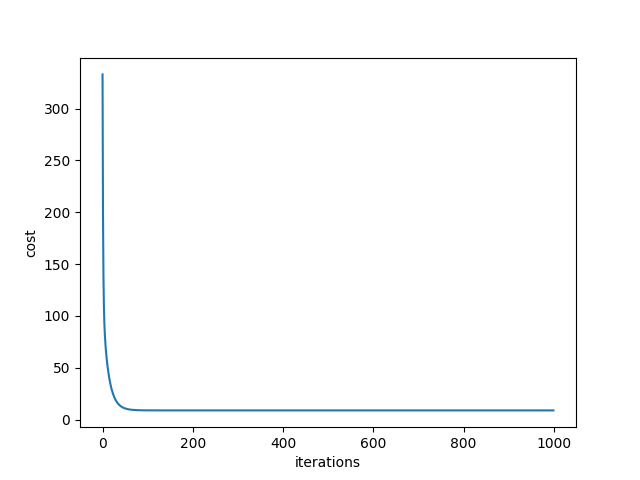

In [124]:
plt_cost3=plt.figure().add_subplot(111,)
plt_cost3.plot(iters3,cost3)
plt_cost3.set_xlabel("iterations")
plt_cost3.set_ylabel("cost")

In [125]:
#removing one feature to plot easily
x31=fat_p
x33=weight
x31=scale(x31,2)
x33=scale(x33,2)
p1=3
p2=3
w3,b3,cost3,iters3=polynomial_regression_gradient_descent((x31,p1),(x33,p2),y=y.to_numpy(),alpha=0.1,cost=True)

Text(0.5, 0, 'BMI')

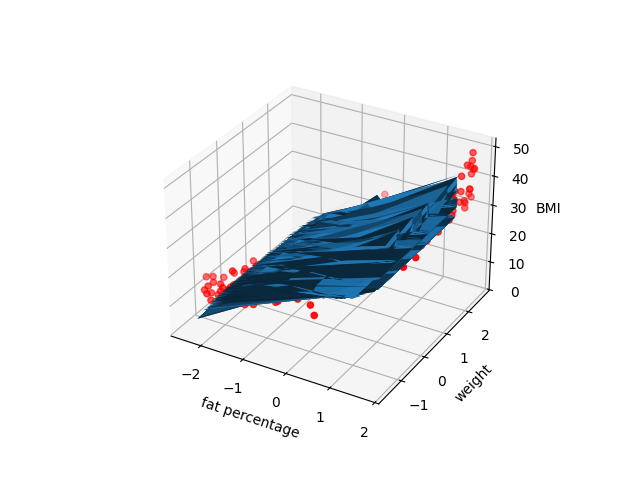

In [126]:
x3=np.array((x31[:500],x33[:500]))
powers=np.array((p1,p2))
X31,X33 = np.meshgrid(x31[:500],x33[:500])
f3 = np.dot(w3,np.power(x3.T,powers).T)+ b3
fig3=plt.figure()
ax3 = fig3.add_subplot(111,projection="3d")
ax3.plot_surface(X31,X33,f3,label="mine")
ax3.scatter(x31[:500],x33[:500],y[:500],color="red")
ax3.set_xlabel("fat percentage")
ax3.set_ylabel("weight")
ax3.set_zlabel("BMI")

In [127]:
#sklearn Polynomial
xs31=fat_p.to_numpy().reshape((-1,1))
xs33=weight.to_numpy().reshape((-1,1))

standardizer = sklearn.preprocessing.StandardScaler()
power= sklearn.preprocessing.PolynomialFeatures(3)
model3 = sklearn.linear_model.LinearRegression()

xs31=standardizer.fit_transform(xs31)
xs33=standardizer.fit_transform(xs33)

p_xs31 = power.fit_transform(xs31)[:,powers[0]]
p_xs33 = power.fit_transform(xs33)[:,powers[1]]

xs3=np.array((p_xs31,p_xs33))
xs3.shape
model3.fit(xs3.T,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


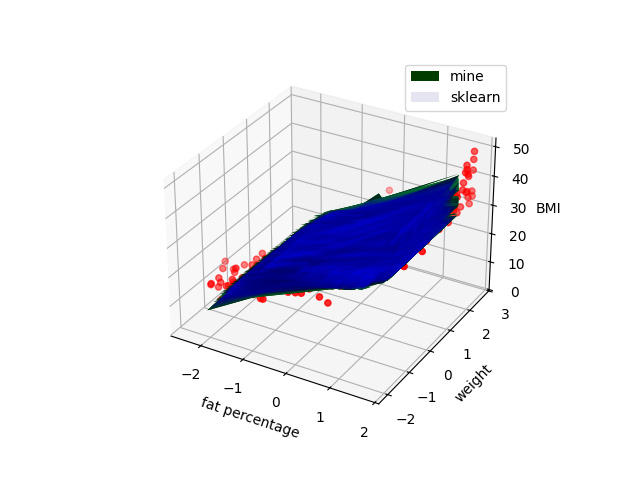

In [128]:
#plot sklearn and my curve

XS31,XS33 = np.meshgrid(xs31[:500],xs33[:500])
fs3 = model3.predict(xs3.T)
fs3=fs3.reshape((1,-1))
fig4=plt.figure()
ax4 = fig4.add_subplot(111,projection="3d",)
ax4.plot_surface(X31,X33,f3[:500],label="mine",color="green",alpha=1)
ax4.plot_surface(XS31,XS33,fs3[:,:500],label="sklearn",color="blue",alpha=0.1)
ax4.scatter(x31[:500],x32[:500],y[:500],color="red")
ax4.set_xlabel("fat percentage")
ax4.set_ylabel("weight")
ax4.set_zlabel("BMI")
ax4.legend()

In [129]:
df["gender_value"] = 0
df.loc[df.Gender == "Male", "gender_value"] = 1

In [130]:
gender = df["gender_value"].to_numpy().reshape(-1)
height = df["Height (m)"].to_numpy().reshape(-1)
height=np.sort(height)
gender=np.sort(gender)


In [131]:

male = gender[gender == 1]
female = gender[gender == 0]

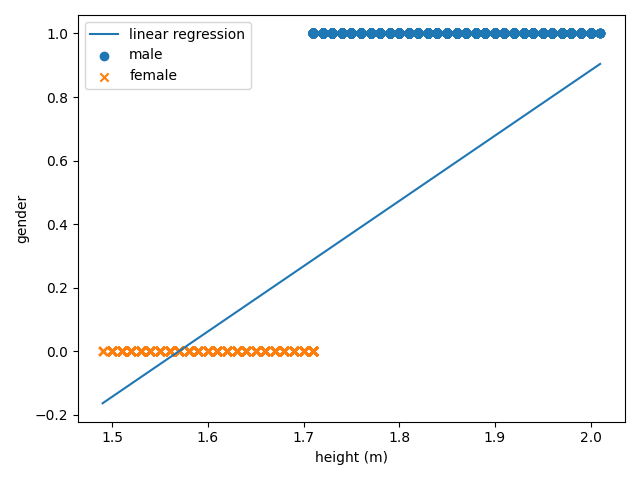

In [139]:
fig5, ax5 = plt.subplots()
w_t,b_t=linear_regression_gradient_descent(scale(height,2),y)
ax5.plot(height,(w_t*scale(height,2)+b_t),label="linear regression")
ax5.scatter((height[len(female):len(female)+len(male)]), male, marker="o", label="male")
ax5.scatter(height[:len(female)], female, marker="x", label="female")
ax5.set_xlabel("height (m)")
ax5.set_ylabel("gender")
ax5.legend()
plt.tight_layout()

In [133]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_gradient_descent(*x:tuple,y:np.ndarray,w_i:float=0,b_i:float=0,alpha:float=0.001,iters:int=1000,cost:bool=False):
    """
    *x (tuple) : features values and their exponent | (x:ndarray,e:float)
    y (ndarray) : target values
    w_i (float) : initial regression coefficient
    b_i (float) : initial interception value
    alpha (float) : value of learning rate
    iters (int) : number of gradient descent iterations
    cost (bool) : return cost function and number of iteration for learning curve
    """
    w=np.full(len(x),w_i,dtype="float64").reshape((1,-1))
    b=b_i
    a=alpha
    xa=[]
    e=[]
    for i in range(len(x)):
        xa.append(x[i][0])
    for i in range(len(x)):
        e.append(x[i][1])
    x=np.array(xa)
    e=np.array(e)
    m=len(x[0])
    x=np.power(x.T,e)
    cost_history=[]    #saving data for learning curve
    x_iters=np.arange(0,iters)
    for _ in range(iters):
        z=np.dot(w,x.T) + b
        f_wb=sigmoid(z)
        j_wb=(-1/(m)) * np.sum(y*np.log(f_wb)+(1-y)*np.log(1-f_wb))
        
        dj_dw = (1/m) * np.dot((f_wb-y),x)
        dj_db = (1/m) * np.sum((f_wb-y))
        cost_history.append(j_wb)
        
        w-=a*dj_dw
        b-=a*dj_db
    match cost:
        case False:
           return w,b
        case True:
            return w,b,cost_history,x_iters
        case _ :
            raise ValueError("Invalid input!")

In [140]:
y=gender
x4 = scale(height, 2)
w4, b4, cost4,iters4 =logistic_regression_gradient_descent((x4,1), y=y, alpha=0.1, iters=10000,cost=True)

Text(0, 0.5, 'cost')

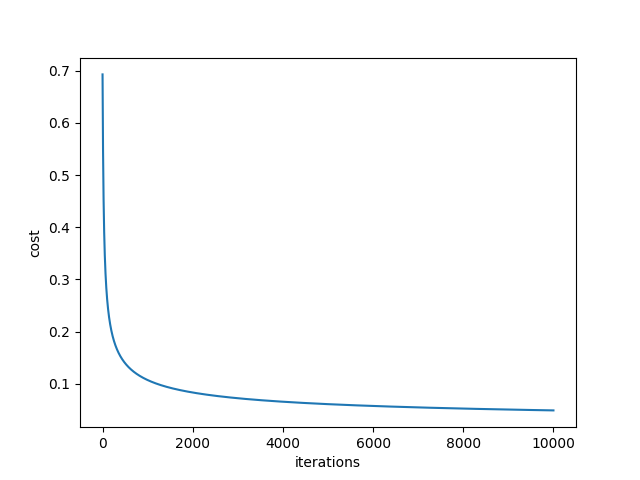

In [141]:
plt_cost4=plt.figure().add_subplot(111,)
plt_cost4.plot(iters4,cost4)
plt_cost4.set_xlabel("iterations")
plt_cost4.set_ylabel("cost")


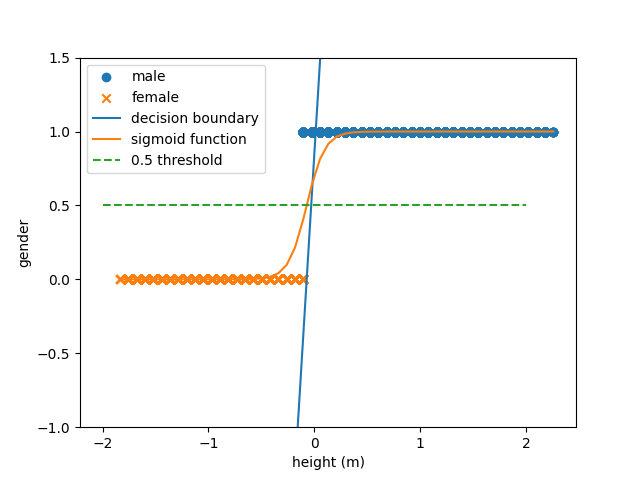

In [142]:
z=w4 * x4 + b4
z=z.reshape(-1)
fig6, ax6 = plt.subplots()
ax6.scatter((x4[len(female):len(female)+len(male)]), male, marker="o", label="male")
ax6.scatter(x4[:len(female)], female, marker="x", label="female")
ax6.set_xlabel("height (m)")
ax6.set_ylabel("gender")
ax6.set_ylim(-1,1.5)
ax6.plot(x4,z, label='decision boundary')
ax6.plot(x4,sigmoid(z),label='sigmoid function')
ax6.plot(np.linspace(-2,2,10),np.linspace(0.5,0.5,10),label="0.5 threshold",linestyle="dashed")
ax6.legend()

In [ ]:
# sklearn logistic
xs4=x4

standardizer = sklearn.preprocessing.StandardScaler()
model4 = sklearn.linear_model.LogisticRegression()

xs4=standardizer.fit_transform(xs4.reshape(-1,1))


model4.fit(xs4,y,)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


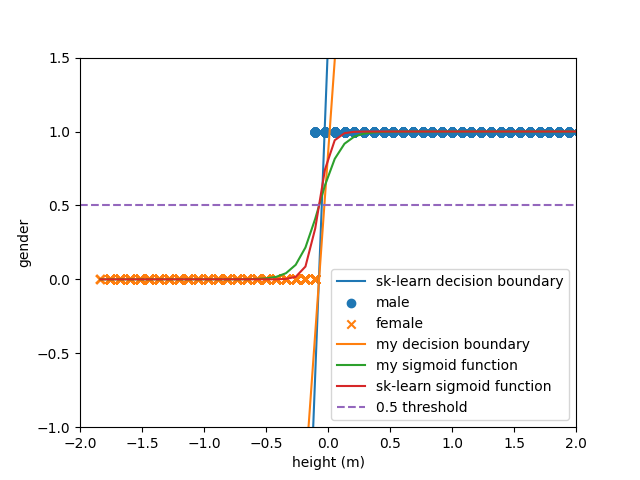

In [ ]:
ws4 = model4.coef_ 
bs4 = model4.intercept_
zs4= ws4*xs4+bs4 
fig7, ax7 = plt.subplots()
ax7.plot(x4,zs4, label='sk-learn decision boundary')
ax7.scatter((x4[len(female):len(female)+len(male)]), male, marker="o", label="male")
ax7.scatter(x4[:len(female)], female, marker="x", label="female")
ax7.set_xlabel("height (m)")
ax7.set_ylabel("gender")
ax7.set_ylim(-1,1.5)
ax7.set_xlim(-2,2)
ax7.plot(x4,z, label='my decision boundary')
ax7.plot(x4,sigmoid(z),label='my sigmoid function')
ax7.plot(x4,sigmoid(zs4.reshape(-1)),label='sk-learn sigmoid function')
ax7.plot(np.linspace(-2,2,10),np.linspace(0.5,0.5,10),label="0.5 threshold",linestyle="dashed")
ax7.legend()